# NoteBook sur le cristal Ba2NF #

## 0. Importation des modules ##

In [91]:
from pymatgen.core import Lattice,Structure
from pymatgen.ext.matproj import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
import numpy as np
import pandas as pd
import scipy as sc
import itertools
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from pymatgen.analysis.diffraction.xrd import XRDCalculator

## 1. Importation de la structure ##

In [92]:
with MPRester("oq0PgNNYTST8xQ2xXfJpkLwNQFB5QgBT") as mpr:
    structure = mpr.get_structure_by_material_id("mp-1018096")
    ph_dos = mpr.get_phonon_dos_by_material_id("mp-1018096")
    N_at = len(structure)

print(structure)

Full Formula (Ba2 N1 F1)
Reduced Formula: Ba2NF
abc   :   4.021645   4.021645   7.067405
angles:  73.469798  73.469807  59.999990
pbc   :       True       True       True
Sites (4)
  #  SP            a          b        c    magmom
---  ----  ---------  ---------  -------  --------
  0  Ba     0.757641   0.757641  0.72708        -0
  1  Ba     0.242359   0.242359  0.27292        -0
  2  N      0.5        0.5       0.5             0
  3  F     -0         -0         0              -0


## 2. Analyse de la maille élémentaire du Ba2NF ##

In [93]:
# Obtention des structures
spaceAnalyzer = SpacegroupAnalyzer(structure)
primitive = spaceAnalyzer.get_primitive_standard_structure()
conventional = spaceAnalyzer.get_conventional_standard_structure()

# Obtention du type de maille
lattice_type = spaceAnalyzer.get_lattice_type()
crystal = spaceAnalyzer.get_crystal_system()
group = spaceAnalyzer.get_point_group_symbol()

#Obtension du réseau direct
direct_vectors_primitive = primitive.lattice.matrix
longueurs_direct_primitive = primitive.lattice.abc
angles_direct_primitive = primitive.lattice.angles
direct_vectors_conventionnel = conventional.lattice.matrix
longueurs_direct_conventionnel = conventional.lattice.abc
angles_direct_conventionnel = conventional.lattice.angles

#Obtension du réseau réciproque
reciprocal_vectors_primitive = primitive.lattice.reciprocal_lattice.matrix
longueurs_reciprocal_primitive = primitive.lattice.reciprocal_lattice.abc
angles_reciprocal_primitive = primitive.lattice.reciprocal_lattice.angles
reciprocal_vectors_conventionnel = conventional.lattice.reciprocal_lattice.matrix
longueurs_reciprocal_conventionnel = conventional.lattice.reciprocal_lattice.abc
angles_reciprocal_conventionnel = conventional.lattice.reciprocal_lattice.angles

In [94]:
#Visualisation
def plot_structure_simple(structure):
    fig = go.Figure()
    coords = np.array(structure.cart_coords)
    species = [str(site.specie) for site in structure]
    color_map = {"Ba": "green", "N": "blue", "F": "red"}
    colors = [color_map.get(s, "black") for s in species]
    fig.add_trace(go.Scatter3d(
        x=coords[:, 0],
        y=coords[:, 1],
        z=coords[:, 2],
        mode="markers+text",
        text=species,
        textposition="top center",
        marker=dict(size=6, color=colors),
        showlegend=False   # ⭐ enlève "Trace 0"
    ))
    lattice = structure.lattice.matrix
    origin = np.array([0, 0, 0])
    a, b, c = lattice
    corners = [origin, a, b, c, a + b, a + c, b + c, a + b + c]
    edges = [(0, 1), (0, 2), (0, 3), (1, 4), (1, 5), (2, 4), (2, 6), (3, 5), (3, 6), (4, 7), (5, 7), (6, 7)]
    for i, j in edges:
        fig.add_trace(go.Scatter3d(
            x=[corners[i][0], corners[j][0]],
            y=[corners[i][1], corners[j][1]],
            z=[corners[i][2], corners[j][2]],
            mode="lines",
            line=dict(color="black"),
            showlegend=False   # ⭐ important aussi ici
        ))
    fig.update_layout(
        showlegend=False,  # ⭐ sécurité globale
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False)
        ),
        margin=dict(l=0, r=0, t=0, b=0)
    )
    return fig

In [95]:
#Affichage des résultats
resultats = [
    ("     ANALYSE DE LA MAILLE DU CRISTAL     ",""),
    ("",""),
    ("=====Informations cristallographiques=====",""),
    ("Type de maille",lattice_type),
    ("Système cristallin",crystal),
    ("Groupe ponctuel",group),
    ("",""),
    ("=====Maille primitive=====",""),
    ("-----Réseau direct-----",""),
    ("Vecteur a",direct_vectors_primitive[0]),
    ("Vecteur b",direct_vectors_primitive[1]),
    ("Vecteur c",direct_vectors_primitive[2]),
    ("Longueurs (a,b,c)",longueurs_direct_primitive),
    ("Angles (α,β,γ)", angles_direct_primitive),
    ("",""),
    ("-----Réseau réciproque-----",""),
    ("Vecteur a*",reciprocal_vectors_primitive[0]),
    ("Vecteur b*",reciprocal_vectors_primitive[1]),
    ("Vecteur c*",reciprocal_vectors_primitive[2]),
    ("Longueurs (a*,b*,c*)",longueurs_reciprocal_primitive),
    ("Angles (α*,β*,γ*)", angles_reciprocal_primitive),
    ("",""),
    ("=====Maille conventionnelle=====",""),
    ("-----Réseau direct-----",""),
    ("Vecteur a",direct_vectors_conventionnel[0]),
    ("Vecteur b",direct_vectors_conventionnel[1]),
    ("Vecteur c",direct_vectors_conventionnel[2]),
    ("Longueurs (a,b,c)",longueurs_direct_conventionnel),
    ("Angles (α,β,γ)", angles_direct_conventionnel),
    ("",""),
    ("-----Réseau réciproque-----",""),
    ("Vecteur a*",reciprocal_vectors_conventionnel[0]),
    ("Vecteur b*",reciprocal_vectors_conventionnel[1]),
    ("Vecteur c*",reciprocal_vectors_conventionnel[2]),
    ("Longueurs (a*,b*,c*)",longueurs_reciprocal_conventionnel),
    ("Angles (α*,β*,γ*)", angles_reciprocal_conventionnel)    
]

def print_result():
    data_frame = pd.DataFrame(resultats, columns=["Grandeur","Valeur"])
    for index,row in data_frame.iterrows():
        if row["Grandeur"] == "":
            print()
        else:
            print(f"{row['Grandeur']:<30}{row['Valeur']}")
    fig = plot_structure_simple(conventional)
    fig.show()

Via les différentes fonctions de SpacegroupeAnalyser, nous avons pu obtenir les informations cristallographiques de la maille ainsi que les vecteurs a, b et c ainsi que leurs longueurs et leurs angles, des réseaux direct et réciproques des mailles primitives et conventionnelles. Ces données se trouvent dans la sortie de la cellule suivante. Une représentation de la maille conventionnelle est également viualisable dans un plot suivant le tableau des données obtenues.

In [96]:
print_result()

     ANALYSE DE LA MAILLE DU CRISTAL     

=====Informations cristallographiques=====
Type de maille                rhombohedral
Système cristallin            trigonal
Groupe ponctuel               -3m

=====Maille primitive=====    
-----Réseau direct-----       
Vecteur a                     [-3.72076892e-17  2.32189774e+00  6.67510314e+00]
Vecteur b                     [ 2.01082242 -1.16094887  6.67510314]
Vecteur c                     [-2.01082242 -1.16094887  6.67510314]
Longueurs (a,b,c)             (7.067404829619489, 7.067404829619489, 7.067404829619489)
Angles (α,β,γ)                (33.060392099605124, 33.060392099605124, 33.060392099605124)

-----Réseau réciproque-----   
Vecteur a*                    [3.46909648e-16 1.80403734e+00 3.13762208e-01]
Vecteur b*                    [ 1.56234216 -0.90201867  0.31376221]
Vecteur c*                    [-1.56234216 -0.90201867  0.31376221]
Longueurs (a*,b*,c*)          (1.8311191745036883, 1.831119174503688, 1.8311191745036877)
Angle

## 3. Les effets de trois symétries ##

In [97]:
#Calcul des symétries
sites = conventional.sites
for i, site in enumerate(sites):
    print(f"Atome {i} : {site.specie}")
    print(f"  Coordonnées fractionnaires : {site.frac_coords}")
    print(f"  Coordonnées cartésiennes   : {conventional.lattice.get_cartesian_coords(site.frac_coords)}\n")
    
Ba_sites = [s.frac_coords for s in sites if s.specie.symbol == "Ba"]
N_sites  = [s.frac_coords for s in sites if s.specie.symbol == "N"]
F_sites  = [s.frac_coords for s in sites if s.specie.symbol == "F"]

Ba_pos = Ba_sites[0]
N_pos  = N_sites[0]
F_pos  = F_sites[1]

print("Ba :", Ba_pos)
print("N  :", N_pos)
print("F  :", F_pos)

sga = SpacegroupAnalyzer(conventional)
symmops = sga.get_symmetry_operations()

# Symétrie 1
op1 = symmops[6]
Ba_new = op1.operate(Ba_pos) % 1

# Symétrie 2
op2 = symmops[1]
N_new = op2.operate(N_pos) % 1

# Symétrie 3
op3 = symmops[3]
F_new = op3.operate(F_pos) % 1

Atome 0 : Ba
  Coordonnées fractionnaires : [0.         0.         0.75764002]
  Coordonnées cartésiennes   : [ 0.          0.         15.17197576]

Atome 1 : Ba
  Coordonnées fractionnaires : [0.33333333 0.66666667 0.90902665]
  Coordonnées cartésiennes   : [ 2.01082242  1.16094887 18.20353994]

Atome 2 : Ba
  Coordonnées fractionnaires : [0.66666667 0.33333333 0.09097335]
  Coordonnées cartésiennes   : [ 2.01082242 -1.16094887  1.82176948]

Atome 3 : Ba
  Coordonnées fractionnaires : [1.         0.         0.24235998]
  Coordonnées cartésiennes   : [ 2.01082242 -3.4828466   4.85333366]

Atome 4 : Ba
  Coordonnées fractionnaires : [0.33333333 0.66666667 0.42430668]
  Coordonnées cartésiennes   : [2.01082242 1.16094887 8.49687262]

Atome 5 : Ba
  Coordonnées fractionnaires : [0.66666667 0.33333333 0.57569332]
  Coordonnées cartésiennes   : [ 2.01082242 -1.16094887 11.5284368 ]

Atome 6 : N
  Coordonnées fractionnaires : [0.66666667 0.33333333 0.83333333]
  Coordonnées cartésiennes   : 

In [98]:
#Visualisatin des symétries

def print_symetrie1():
    print("   OPERATION DE SYMETRIE 1")
    print("-----Matrice et vecteur-----")
    print("Matrice R :\n", op1.rotation_matrix)
    print("Vecteur t :", op1.translation_vector)
    print("-----Positions initiale et finale-----")
    print("Position initiale (Ba)    :", Ba_pos)
    print("Position transformée (Ba) :", Ba_new)

def print_symetrie2():
    print("   OPERATION DE SYMETRIE 2")
    print("-----Matrice et vecteur-----")
    print("Matrice R :\n", op2.rotation_matrix)
    print("Vecteur t :", op2.translation_vector)
    print("-----Positions initiale et finale-----")
    print("Position initiale (N)    :", N_pos)
    print("Position transformée (N) :", N_new)

def print_symetrie3():
    print("   OPERATION DE SYMETRIE 3")
    print("-----Matrice et vecteur-----")
    print("Matrice R :\n", op3.rotation_matrix)
    print("Vecteur t :", op3.translation_vector)
    print("-----Positions initiale et finale-----")
    print("Position initiale (F)    :", F_pos)
    print("Position transformée (F) :", F_new)

### a) Première symétrie ###

Pour la première symétrié, nous avons appliqué une inversion selon l'axe $x=y$ dans le plan $xy$ et une inversion selon l'axe $z$. C'est donc une rotation autout de l'axe cristallographique [110] d'ordre 2.

Sa matrice de rotation est $ R=
\begin{pmatrix}
0 & 1 & 0 \\
1 & 0 & 0 \\
0 & 0 & -1
\end{pmatrix}$
et son vecteur de translation est $\tau = (0,0,0)$.

Dans la sortie de la cellule de code suivante, il y a l'atome original de Ba et sa position finale. On remarque qu'elle est identique à celle d'un autre atome de Ba avant l'application de la symétrie. (cfr coordonnées des atomes de la maille dans la sortie de la cellele "Calcul des symétries").

In [99]:
print_symetrie1()

   OPERATION DE SYMETRIE 1
-----Matrice et vecteur-----
Matrice R :
 [[ 0.  1.  0.]
 [ 1.  0.  0.]
 [ 0.  0. -1.]]
Vecteur t : [0. 0. 0.]
-----Positions initiale et finale-----
Position initiale (Ba)    : [0.         0.         0.75764002]
Position transformée (Ba) : [0.         0.         0.24235998]


### b) Deuxième symétrie ###

Pour la deuxième symétrié, nous avons appliqué une inversion centrale. Il s'agit donc d'une opération de symétrie d'ordre 2.

Sa matrice de rotation est $ R=
\begin{pmatrix}
-1 & 0 & 0 \\
0 & -1 & 0 \\
0 & 0 & -1
\end{pmatrix}$
et son vecteur de translation est $\tau = (0,0,0)$.

Dans la sortie de la cellule de code suivante, il y a l'atome original de N et sa position finale. On remarque qu'elle est identique à celle d'un autre atome de N avant l'application de la symétrie. (cfr coordonnées des atomes de la maille dans la sortie de la cellele "Calcul des symétries").

In [100]:
print_symetrie2()

   OPERATION DE SYMETRIE 2
-----Matrice et vecteur-----
Matrice R :
 [[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Vecteur t : [0. 0. 0.]
-----Positions initiale et finale-----
Position initiale (N)    : [0.66666667 0.33333333 0.83333333]
Position transformée (N) : [0.33333333 0.66666667 0.16666667]


### c) Troisième symétrie ###

Pour la troisième symétrié, nous avons appliqué une rotation de 120° dans le plan $xy$ (rotation d'ordre 3) et une inversion selon l'axe $z$. C'est une roto-inversion d'ordre 6.

Sa matrice de rotation est $ R=
\begin{pmatrix}
0 & 1 & 0 \\
-1 & 1 & 0 \\
0 & 0 & -1
\end{pmatrix}$
et son vecteur de translation est $\tau = (0,0,0)$.

Dans la sortie de la cellule de code suivante, il y a l'atome original de F et sa position finale. On remarque qu'elle est identique à celle d'un autre atome de F avant l'application de la symétrie. (cfr coordonnées des atomes de la maille dans la sortie de la cellele "Calcul des symétries").

In [101]:
print_symetrie3()

   OPERATION DE SYMETRIE 3
-----Matrice et vecteur-----
Matrice R :
 [[ 0.  1.  0.]
 [-1.  1.  0.]
 [ 0.  0. -1.]]
Vecteur t : [0. 0. 0.]
-----Positions initiale et finale-----
Position initiale (F)    : [0.66666667 0.33333333 0.33333333]
Position transformée (F) : [0.33333333 0.66666667 0.66666667]


## 4. Zone de Brillouin ##

In [102]:
def plot_brillouin_zone_simple(struc):

    bz_lattice = struc.lattice.reciprocal_lattice
    fig = go.Figure()

    origin = bz_lattice.get_cartesian_coords([0, 0, 0])
    axes = [
        ([1, 0, 0], "a*"),
        ([0, 1, 0], "b*"),
        ([0, 0, 1], "c*")
    ]

    for vec, label in axes:
        end = bz_lattice.get_cartesian_coords(vec)
        fig.add_trace(go.Scatter3d(
            x=[origin[0], end[0]],
            y=[origin[1], end[1]],
            z=[origin[2], end[2]],
            mode="lines+text",
            text=["", label],
            line=dict(color="green")
        ))

    ws = bz_lattice.get_wigner_seitz_cell()
    for iface in range(len(ws)):
        for line in itertools.combinations(ws[iface], 2):
            for jface in range(len(ws)):
                if (iface < jface
                    and any(np.all(line[0] == x) for x in ws[jface])
                    and any(np.all(line[1] == x) for x in ws[jface])):

                    fig.add_trace(go.Scatter3d(
                        x=[line[0][0], line[1][0]],
                        y=[line[0][1], line[1][1]],
                        z=[line[0][2], line[1][2]],
                        mode="lines",
                        line=dict(color="black")
                    ))
    high_sym_k = {
        "Γ": [0, 0, 0],
        "X": [0.5, 0, 0],
        "Y": [0, 0.5, 0],
        "Z": [0, 0, 0.5]
    }

    points = []
    labels = []
    for k, frac in high_sym_k.items():
        cart = bz_lattice.get_cartesian_coords(frac)
        points.append(cart)
        labels.append(k)
    fig.add_trace(go.Scatter3d(
        x=[p[0] for p in points],
        y=[p[1] for p in points],
        z=[p[2] for p in points],
        mode="markers+text",
        text=labels,
        marker=dict(size=5, color="red")
    ))
    fig.update_layout(
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False)
        )
    )
    return fig

La fonction utilisée permet de visualiser la zone de Brillouin du cristal à partir du réseau réciproque associé à la structure. La zone de Brillouin, est définie comme la cellule de Wigner-Seitz du réseau réciproque. Dans cette représentation, les vecteurs de base du réseau réciproque sont d’abord tracés afin de fournir une référence géométrique de l’espace k. La zone de Brillouin est ensuite reconstruite à partir de sa définition géométrique.

Cette visualisation permet d’identifier clairement la géométrie de la zone de Brillouin. Elle est visible dans le sortie de la cellule de code suivante.

In [103]:
fig = plot_brillouin_zone_simple(conventional)
fig.show()

# 4. Diffractogramme #

In [104]:
#Calcul du diffractogramme et des trois premiers pics

def diffractogramme():
    xrd = XRDCalculator(wavelength=1.54060)
    pattern = xrd.get_pattern(conventional)
    hkl = pattern.hkls
    d_hkl = pattern.d_hkls

    # Pic 1
    print("Pic de diffraction n°1\n")
    print("Angle de diffraction (2θ) =", round(pattern.x[0], 4), "[°]")
    print("Intensité relative =", round(pattern.y[0], 4))
    print("Indices hkl =", hkl[0][0]["hkl"])
    print("Multiplicité =", hkl[0][0]["multiplicity"])
    print("Distance interplanaire =", round(d_hkl[0], 4), "[Å]")

    print("\n" + "="*50 + "\n")

    # Pic 2
    print("Pic de diffraction n°2\n")
    print("Angle de diffraction (2θ) =", round(pattern.x[1], 4), "[°]")
    print("Intensité relative =", round(pattern.y[1], 4))
    print("Indices hkl =", hkl[1][0]["hkl"])
    print("Multiplicité =", hkl[1][0]["multiplicity"])
    print("Distance interplanaire =", round(d_hkl[1], 4), "[Å]")

    print("\n" + "="*50 + "\n")

    # Pic 3
    print("Pic de diffraction n°3\n")
    print("Angle de diffraction (2θ) =", round(pattern.x[2], 4), "[°]")
    print("Intensité relative =", round(pattern.y[2], 4))
    print("Indices hkl =", hkl[2][0]["hkl"])
    print("Multiplicité =", hkl[2][0]["multiplicity"])
    print("Distance interplanaire =", round(d_hkl[2], 4), "[Å]")

    #graphique
    xrd.get_plot(conventional, two_theta_range=(0,27))

Pour analyser les trois premier pics du diffractogramme pour un rayonnement X incident Cu Kα de longueur d’onde λ=1.54060 Å, nous avons utilisé les propriétés physiques de la diffraction dans un crystal. En effet, lorsqu'un rayonnement X incident est envoyé sur un cristal, le faisceau est diffracté à cause du réseau atmique et des interférences constructives et destructives apparaissent. L’interférence sera constructive lorque le vecteur d’onde $k$ appartient au plan de Bragg. Ces angles sont calculés grâce loi de Bragg : $2d_{hkl}\sin{(\theta)}=n\lambda$.

L'intensité des pics de diffraction dépend du facteur de forme de l'atome et de la multiplicité des plans de réflexion. La distance entre deux plans $(h,k,l)$ consécutifs du réseau direct est donnée par $d_{hkl}=\frac{2\pi}{\vert v \vert}$.

Tous ces calcules sont réalisées via le module XRDCalculator.

Les valeurs de ces données sont disponibles dans la sortie de la cellule de code suivant ainsi qu'un graphique permettant de visualiser ces pics.

Pic de diffraction n°1

Angle de diffraction (2θ) = 13.2533 [°]
Intensité relative = 3.2022
Indices hkl = (0, 0, 0, 3)
Multiplicité = 2
Distance interplanaire = 6.6751 [Å]


Pic de diffraction n°2

Angle de diffraction (2θ) = 25.9458 [°]
Intensité relative = 0.6478
Indices hkl = (1, 0, -1, 1)
Multiplicité = 12
Distance interplanaire = 3.4313 [Å]


Pic de diffraction n°3

Angle de diffraction (2θ) = 26.6881 [°]
Intensité relative = 27.5067
Indices hkl = (0, 0, 0, 6)
Multiplicité = 2
Distance interplanaire = 3.3376 [Å]


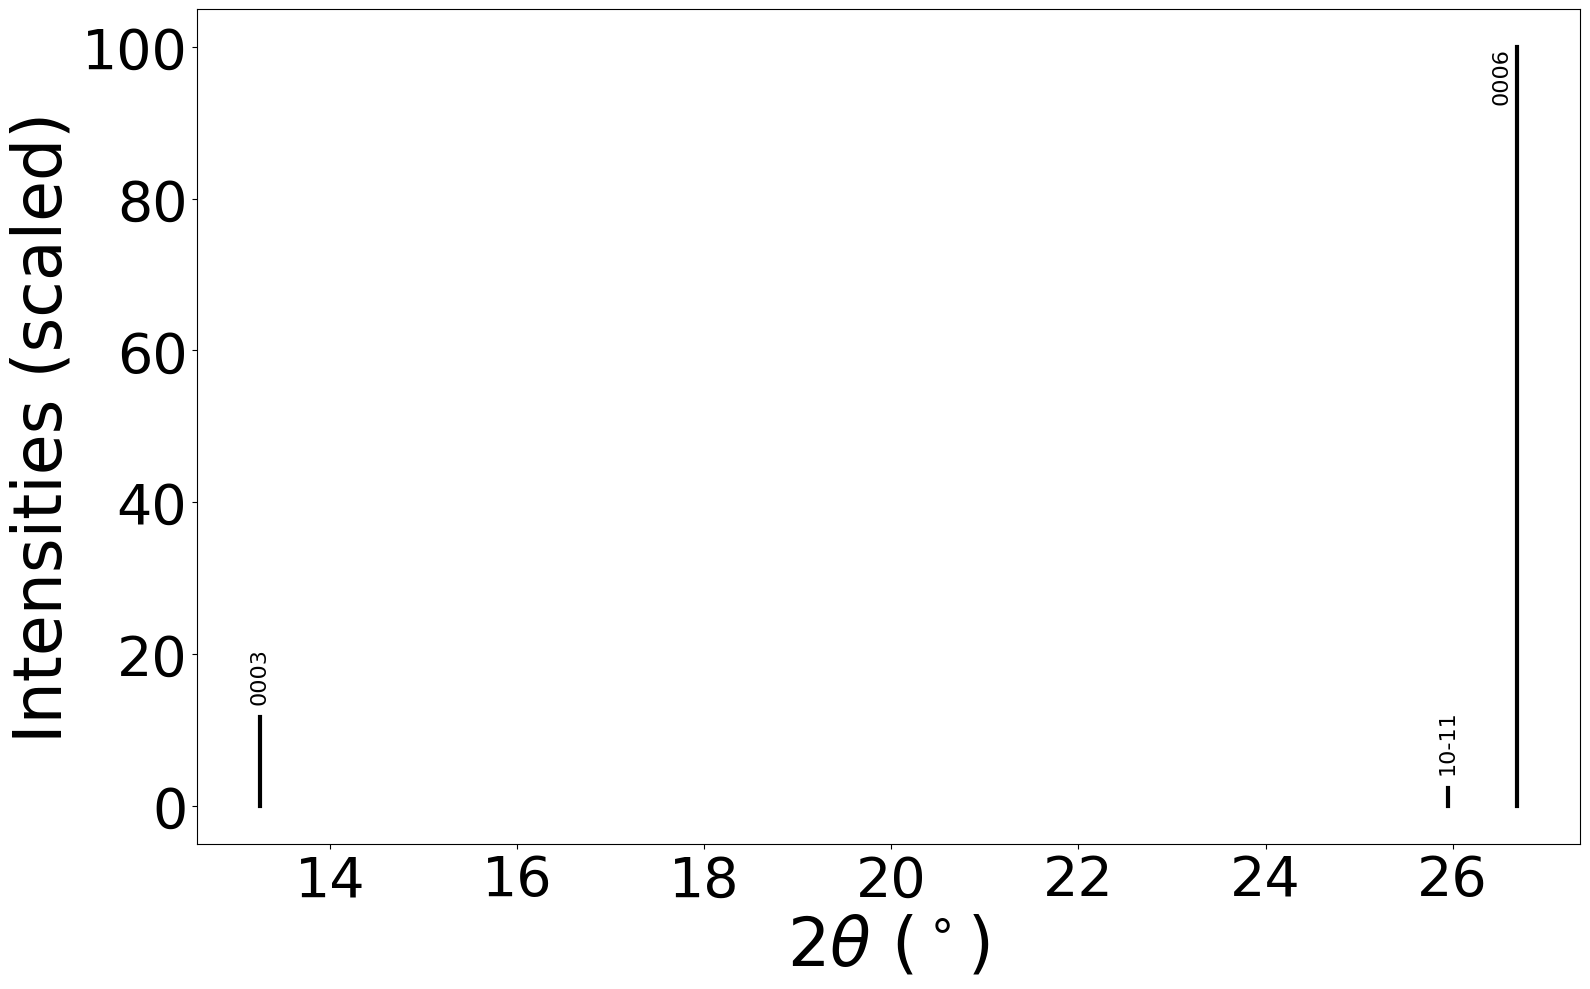

In [105]:
diffractogramme()

# 5. Bande interdite #

In [106]:
# EXTRACTION
API_KEY = "oq0PgNNYTST8xQ2xXfJpkLwNQFB5QgBT"
MP_ID = "mp-1018096"
with MPRester(API_KEY) as mpr:
    bs = mpr.get_bandstructure_by_material_id(MP_ID, line_mode=True)
print(bs.get_band_gap())

AttributeError: get_bandstructure_by_material_id is not an attribute of this implementation of MPRester, which only supports functionality used by 80% of users. If you are looking for the full functionality MPRester, pls install the mp-api .

La bande interdite correspond à l’intervalle d'énergie séparant la bande de valence de la bande de conduction du matériau. Pour qu’un électron puisse passer de la bande de valence à la bande de conduction, il doit absorber une énergie au moins égale à celle de cette bande interdite.Il pourra donc contribuer à la conduction électrique.

Dans le cas du Ba₂NF, l’énergie de la bande interdite est Eg = 1.0924 eV. Cette valeur caractérise un semi-conducteur, car elle est intermédiaire entre celle des conducteurs (gap nul) et des isolants (gap élevé).

La transition électronique s’effectue au point de haute symétrie F de la zone de Brillouin, aussi bien pour le maximum de la bande de valence que pour le minimum de la bande de conduction (transition F → F).
La bande interdite est donc directe, ce qui signifie que le maximum de la bande de valence et le minimum de la bande de conduction se situent au même vecteur d’onde k.
Dans ce cas (semi-conducteurs à transmission directe), les transitions électroniques peuvent se produire sans changement de vecteur d’onde.

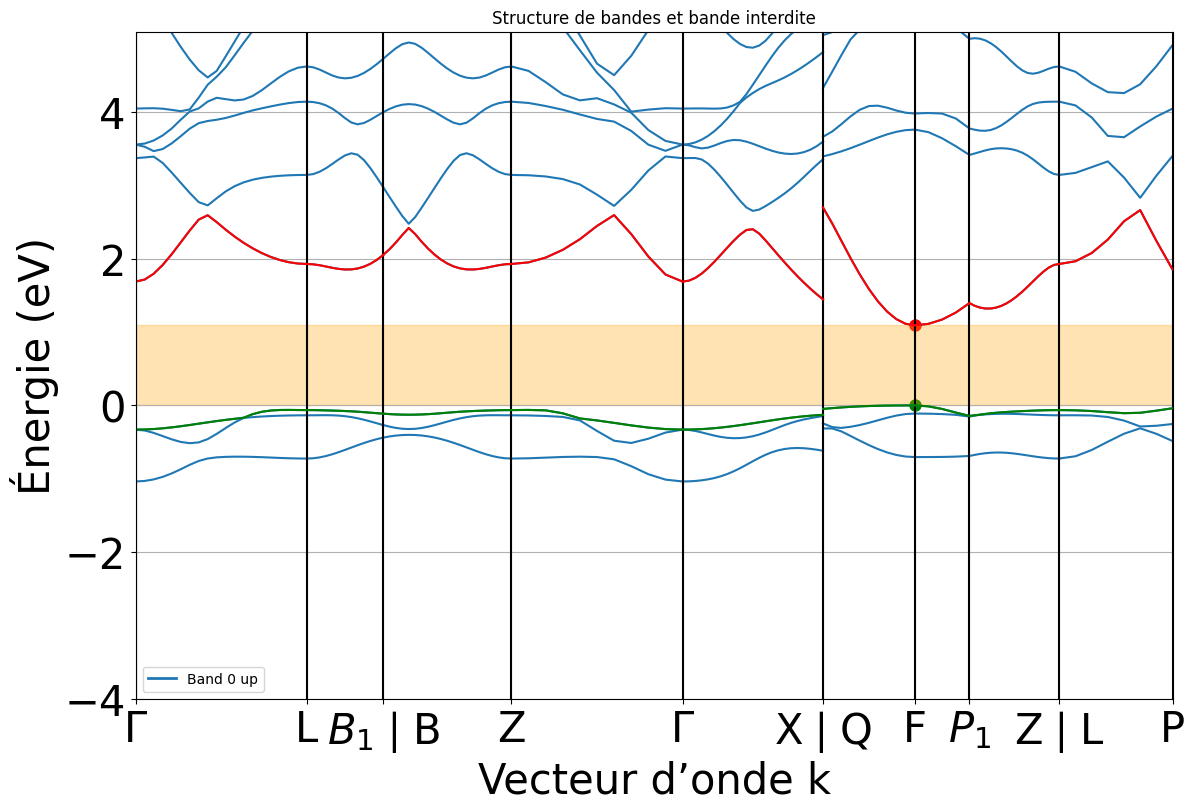


=== BANDE INTERDITE ===
Gap = 1.0924 eV
Direct ? True
Transition : F-F

Dernière bande de valence :
Énergie VBM = 2.41 eV
Vecteur k (cartésien) = [ 0.         -0.89744508 -0.30846207]
Indices des bandes de valence : [15]

Première bande de conduction :
Énergie CBM = 3.50 eV
Vecteur k (cartésien) = [ 0.         -0.89744508 -0.30846207]
Indices des bandes de conduction : [16]

Gap (calcul manuel) = 1.09 eV


In [ ]:
from mp_api.client import MPRester
from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.electronic_structure.core import Spin
import numpy as np
import matplotlib.pyplot as plt

# EXTRACTION DONNEES
bsplot = BSPlotter(bs)
bsdata = bsplot.bs_plot_data()

distances = bsdata['distances']
energy = bsdata['energy']

# VBM / CBM
vbm = bs.get_vbm()
cbm = bs.get_cbm()

vbm_band_index = vbm['band_index'][Spin.up][0]
cbm_band_index = cbm['band_index'][Spin.up][0]

# PLOT
bsplot.get_plot()

for i in range(len(distances)):
    plt.plot(distances[i], energy['1'][i][vbm_band_index], color='green')
    plt.plot(distances[i], energy['1'][i][cbm_band_index], color='red')

for (x, y) in bsdata['vbm']:
    plt.scatter(x, y, color='green', s=60)

for (x, y) in bsdata['cbm']:
    plt.scatter(x, y, color='red', s=60)

vbm_energy = max([y for (x, y) in bsdata["vbm"]])
cbm_energy = min([y for (x, y) in bsdata["cbm"]])

x_min = distances[0][0]
x_max = distances[-1][-1]

plt.fill_between([x_min, x_max],
                 vbm_energy,
                 cbm_energy,
                 color="orange",
                 alpha=0.3)

# AFFICHAGE
plt.title("Structure de bandes et bande interdite")
plt.xlabel("Vecteur d’onde k")
plt.ylabel("Énergie (eV)")
plt.grid(True)
plt.show()

# RESULTATS NUMERIQUES
gap = bs.get_band_gap()

indices_vbm = list(vbm["band_index"][Spin.up])
indices_cbm = list(cbm["band_index"][Spin.up])
kpoint_vbm = vbm["kpoint"].cart_coords
kpoint_cbm = cbm["kpoint"].cart_coords

print("\n=== BANDE INTERDITE ===")
print("Gap =", gap["energy"], "eV")
print("Direct ?", gap["direct"])
print("Transition :", gap["transition"])

print("\nDernière bande de valence :")
print("Énergie VBM = {:.2f} eV".format(vbm["energy"]))
print("Vecteur k (cartésien) =", kpoint_vbm)
print("Indices des bandes de valence :", indices_vbm)

print("\nPremière bande de conduction :")
print("Énergie CBM = {:.2f} eV".format(cbm["energy"]))
print("Vecteur k (cartésien) =", kpoint_cbm)
print("Indices des bandes de conduction :", indices_cbm)

print("\nGap (calcul manuel) = {:.2f} eV".format(cbm["energy"] - vbm["energy"]))

# 6. Dispersion #

La dispersion des bandes électroniques décrit la variation de l’énergie E(k) en fonction du vecteur d’onde k dans l’espace réciproque. Elle est directement liée aux propriétés de transport des électrons dans le matériau.
Dans un diagramme de bandes, la dispersion correspond à la pente des courbes E(k).
La vitesse de groupe des électrons étant proportionnelle à la pente dE/dk, une forte dispersion indique que les électrons peuvent se déplacer plus facilement dans le cristal, tandis qu’une faible dispersion traduit des électrons plus localisés.


=== DISPERSION ===
Valence max dispersion : 0.491628 (segment 6)
Valence min dispersion : 0.041340 (segment 8)
Conduction max dispersion : 3.295563 (segment 5)
Conduction min dispersion : 0.123854 (segment 8)

=== DIRECTIONS ===
0 : $\Gamma$–L
1 : L–L
2 : L–$B_1$$\mid$B
3 : $B_1$$\mid$B–Z
4 : Z–Z
5 : Z–$\Gamma$
6 : $\Gamma$–$\Gamma$
7 : $\Gamma$–X$\mid$Q
8 : X$\mid$Q–F
9 : F–F
10 : F–$P_1$
11 : $P_1$–$P_1$
12 : $P_1$–Z$\mid$L
13 : Z$\mid$L–P


<Figure size 640x480 with 0 Axes>

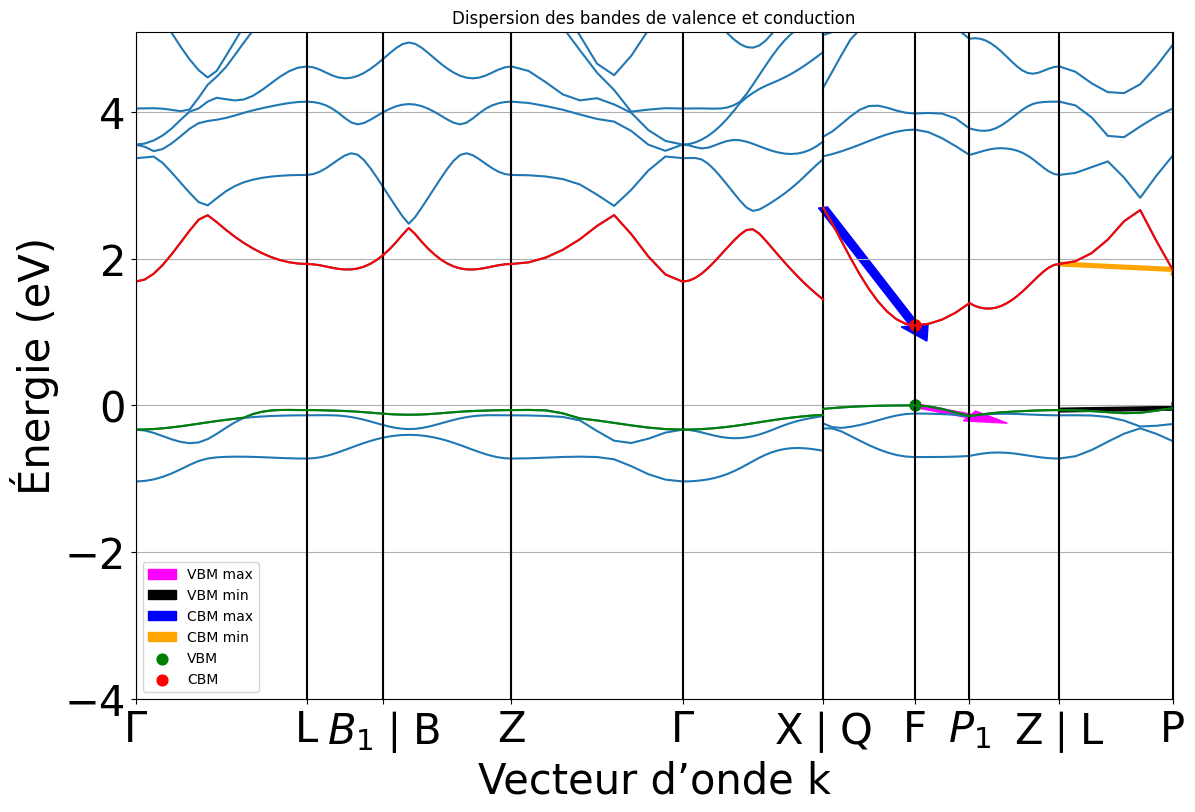

In [111]:
# CALCUL DISPERSION
num_segments = len(distances)

dx = np.zeros(num_segments)
dy_vbm = np.zeros(num_segments)
dy_cbm = np.zeros(num_segments)

m_vbm = np.zeros(num_segments)
m_cbm = np.zeros(num_segments)

for i in range(num_segments):

    dx[i] = distances[i][-1] - distances[i][0]

    dy_vbm[i] = energy['1'][i][vbm_band_index][-1] - energy['1'][i][vbm_band_index][0]
    dy_cbm[i] = energy['1'][i][cbm_band_index][-1] - energy['1'][i][cbm_band_index][0]

    m_vbm[i] = dy_vbm[i] / dx[i]
    m_cbm[i] = dy_cbm[i] / dx[i]

# DISPERSION MAX / MIN
idx_max_vbm = np.argmax(abs(m_vbm))
idx_min_vbm = np.argmin(abs(m_vbm))
idx_max_cbm = np.argmax(abs(m_cbm))
idx_min_cbm = np.argmin(abs(m_cbm))

print("\n=== DISPERSION ===")
print("Valence max dispersion : {:.6f} (segment {})".format(abs(m_vbm[idx_max_vbm]), idx_max_vbm))
print("Valence min dispersion : {:.6f} (segment {})".format(abs(m_vbm[idx_min_vbm]), idx_min_vbm))
print("Conduction max dispersion : {:.6f} (segment {})".format(abs(m_cbm[idx_max_cbm]), idx_max_cbm))
print("Conduction min dispersion : {:.6f} (segment {})".format(abs(m_cbm[idx_min_cbm]), idx_min_cbm))

# NOMS DES DIRECTIONS
labels = bsdata["ticks"]["label"]

segments = []
for i in range(len(labels) - 1):
    segments.append(f"{labels[i]}–{labels[i+1]}")

print("\n=== DIRECTIONS ===")
for i, seg in enumerate(segments):
    print(i, ":", seg)

# PLOT
plt.figure()
bsplot.get_plot()

for i in range(len(distances)):
    plt.plot(distances[i], energy['1'][i][vbm_band_index], color='green')
    plt.plot(distances[i], energy['1'][i][cbm_band_index], color='red')

# FLECHES AVEC LABELS
plt.arrow(distances[idx_max_vbm][0],
          energy['1'][idx_max_vbm][vbm_band_index][0],
          dx[idx_max_vbm],
          dy_vbm[idx_max_vbm],
          color='magenta', width=0.05, label="VBM max")

plt.arrow(distances[idx_min_vbm][0],
          energy['1'][idx_min_vbm][vbm_band_index][0],
          dx[idx_min_vbm],
          dy_vbm[idx_min_vbm],
          color='black', width=0.05, label="VBM min")

plt.arrow(distances[idx_max_cbm][0],
          energy['1'][idx_max_cbm][cbm_band_index][0],
          dx[idx_max_cbm],
          dy_cbm[idx_max_cbm],
          color='blue', width=0.05, label="CBM max")

plt.arrow(distances[idx_min_cbm][0],
          energy['1'][idx_min_cbm][cbm_band_index][0],
          dx[idx_min_cbm],
          dy_cbm[idx_min_cbm],
          color='orange', width=0.05, label="CBM min")

# POINTS VBM / CBM
for (kx, ky) in bsdata['vbm']:
    plt.scatter(kx, ky, color='green', s=60, label="VBM")

for (kx, ky) in bsdata['cbm']:
    plt.scatter(kx, ky, color='red', s=60, label="CBM")


# LEGENDE 
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# AFFICHAGE
plt.title("Dispersion des bandes de valence et conduction")
plt.xlabel("Vecteur d’onde k")
plt.ylabel("Énergie (eV)")
plt.grid(True)
plt.show()

# 7. Masse effective #

Il est souvent intéressant de décrire les électrons comme des particules libres dont la masse effective varie, plutôt que comme des particules de masse fixée évoluant dans un potentiel cristallin. Cette masse effective peut être positive ou négative, et supérieure ou inférieure à la masse réelle de l’électron.

La masse effective est définie par le tenseur des dérivées secondes de l’énergie E par rapport au vecteur d’onde k :

$ m^*_{ij} = \left( \frac{\partial^2 E}{\partial k_i \partial k_j} \right)^{-1}$

La courbure des bandes d’énergie fournit une indication directe de la capacité des électrons à accélérer sous l’effet d’un champ électrique. Lorsqu’une bande est peu dispersive (plate), la masse effective est élevée et les porteurs de charge sont peu mobiles. À l’inverse, une bande fortement dispersée correspond à une faible masse effective et donc à une mobilité plus élevée.

Dans le cas du matériau Ba₂NF, nous nous intéressons à la masse effective au sommet de la dernière bande de valence et au bas de la première bande de conduction. Afin de simplifier le calcul, nous supposons une dispersion parabolique au voisinage de ces extrema.

L’énergie peut alors être approximée par une relation quadratique de la forme :

\begin{equation*}
y = a k^2 + b k + c
\end{equation*}

Cette approximation permet d’exprimer la masse effective comme étant inversement proportionnelle à la courbure de la bande au voisinage du point considéré.


Résultats de l'ajustement quadratique autour du VBM :

Parabole : y(k) = -1.506e+00 k² + 1.242e+01 k + -2.560e+01
Masse effective = 2.304e-30 kg
Masse relative = 2.530 m_e


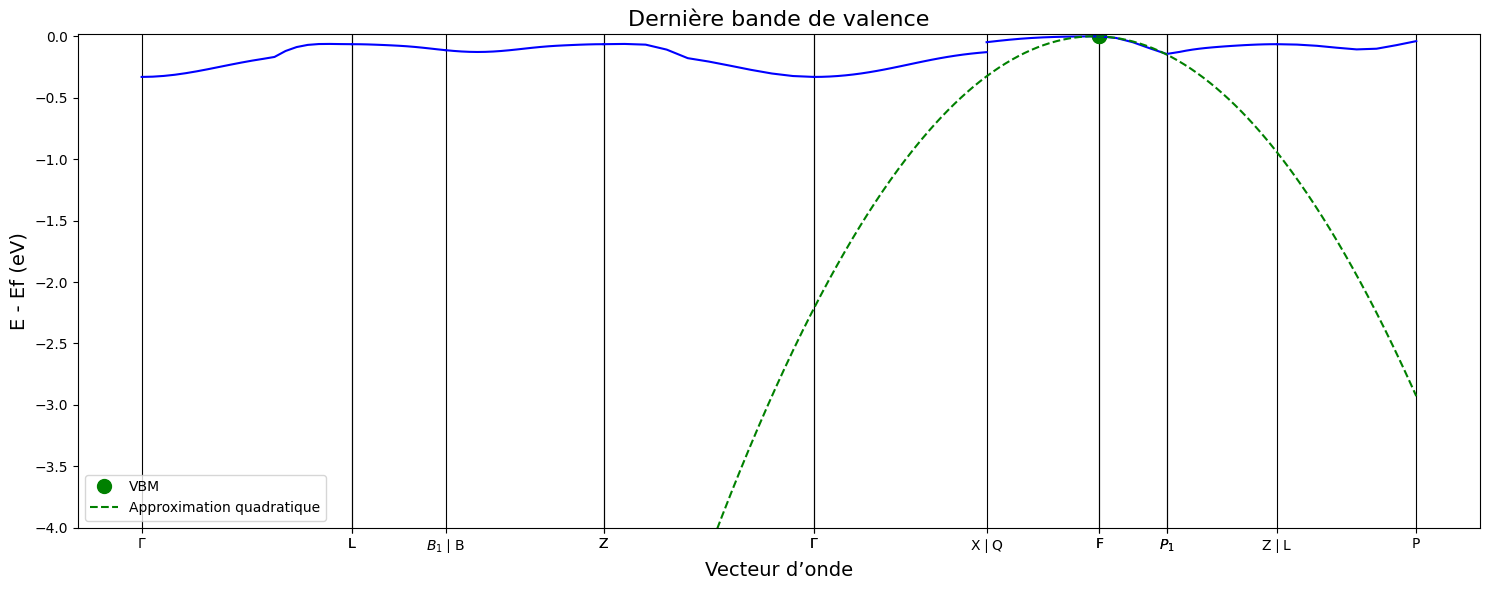

In [119]:
from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.electronic_structure.core import Spin
import numpy as np
import matplotlib.pyplot as plt
from mp_api.client import MPRester

# ==============================
# IMPORT DATA
# ==============================
bsplot = BSPlotter(bs)
bsdata = bsplot.bs_plot_data()

distances = bsdata['distances']
energy = bsdata['energy']
distance = bsdata['ticks']['distance']

vbm_coord = bsdata['vbm']

vbm = bs.get_vbm()
vbm_band_index = vbm['band_index'][Spin.up][0]

# Constantes
hbar2 = ((6.62607004e-34) / (2 * np.pi))**2
electronvolt = 1.602176634e-19
angstrom = 1e-10
m_e = 9.10938356e-31

# Figure
fig, ax = plt.subplots(figsize=(15, 6))

for d in distance:
    ax.axvline(d, color="black", linewidth=0.8)

# VBM point
for i, (x, y) in enumerate(vbm_coord):
    if i == 0:
        ax.plot(x, y, 'og', markersize=10, label='VBM')
    else:
        ax.plot(x, y, 'og', markersize=10)

# bande de valence
for i in range(len(distances)):
    ax.plot(distances[i], energy['1'][i][vbm_band_index], 'b')

# axes
ax.set_xticks(distance)
ax.set_xticklabels(bsdata['ticks']['label'])
ax.set_xlabel('Vecteur d’onde', fontsize=14)
ax.set_ylabel('E - Ef (eV)', fontsize=14)
ax.set_title('Dernière bande de valence', fontsize=16)
ax.set_ylim(-4, None)

# SELECTION POINTS AUTOUR VBM
k0, E0 = vbm_coord[0]

k_points = [k0]
energies = [E0]

points_proches = []

for i in range(len(distances)):
    for j in range(len(distances[i])):
        k = distances[i][j]
        E = energy['1'][i][vbm_band_index][j]
        
        if k != k0:
            points_proches.append((abs(k - k0), k, E))

points_proches.sort(key=lambda x: x[0])

k_points.append(points_proches[0][1])
energies.append(points_proches[0][2])

k_points.append(points_proches[1][1])
energies.append(points_proches[1][2])

k_points = np.array(k_points)
energies = np.array(energies)

# Fit
coeffs = np.polyfit(k_points, energies, 2)

m_eff = hbar2 / (2 * abs(coeffs[0]) * electronvolt * angstrom**2)
m_eff_ratio = m_eff / m_e

x_fit = np.linspace(distance[0], distance[-1], 1000)
ax.plot(x_fit, np.polyval(coeffs, x_fit), 'g--', label='Approximation quadratique')

# Résultats
print("\nRésultats de l'ajustement quadratique autour du VBM :\n")
print(f"Parabole : y(k) = {coeffs[0]:.3e} k² + {coeffs[1]:.3e} k + {coeffs[2]:.3e}")
print(f"Masse effective = {m_eff:.3e} kg")
print(f"Masse relative = {m_eff_ratio:.3f} m_e")

ax.legend()
plt.tight_layout()
plt.show()

### Masse effective des électrons de la bande de valence
L’ajustement numérique donne la parabole suivante :
$$ y(k) = -1{,}506 \cdot k^2 + 1{,}242 \times 10^1 \cdot k - 2{,}560 \times 10^1 $$

À partir de la dérivée seconde de cette parabole, nous obtenons :
$$\frac{d^2E}{dk^2} = -3.012 \ \text{eV}\cdot\text{\AA}^2$$

En utilisant la relation :
$$ m^* = \frac{\hbar^2}{\frac{d^2E}{dk^2}} $$

nous calculons une masse effective des trous de :

$$
m^* = 2{,}304 \times 10^{-30} \ \text{kg}
$$

Cette valeur correspond à environ $2{,}53\, m_e$. Elle traduit une courbure relativement faible de la bande de valence, ce qui signifie que les trous se comportent comme des particules relativement lourdes et peu mobiles dans ce matériau.


Résultats de l'ajustement quadratique autour du CBM :

Parabole : y(k) = 3.518e+00·k² + -2.916e+01·k + 6.150e+01
Dérivée seconde : 7.037e+00 eV·Å²
Masse effective : 9.864e-31 kg
Masse relative : 1.083 m_e


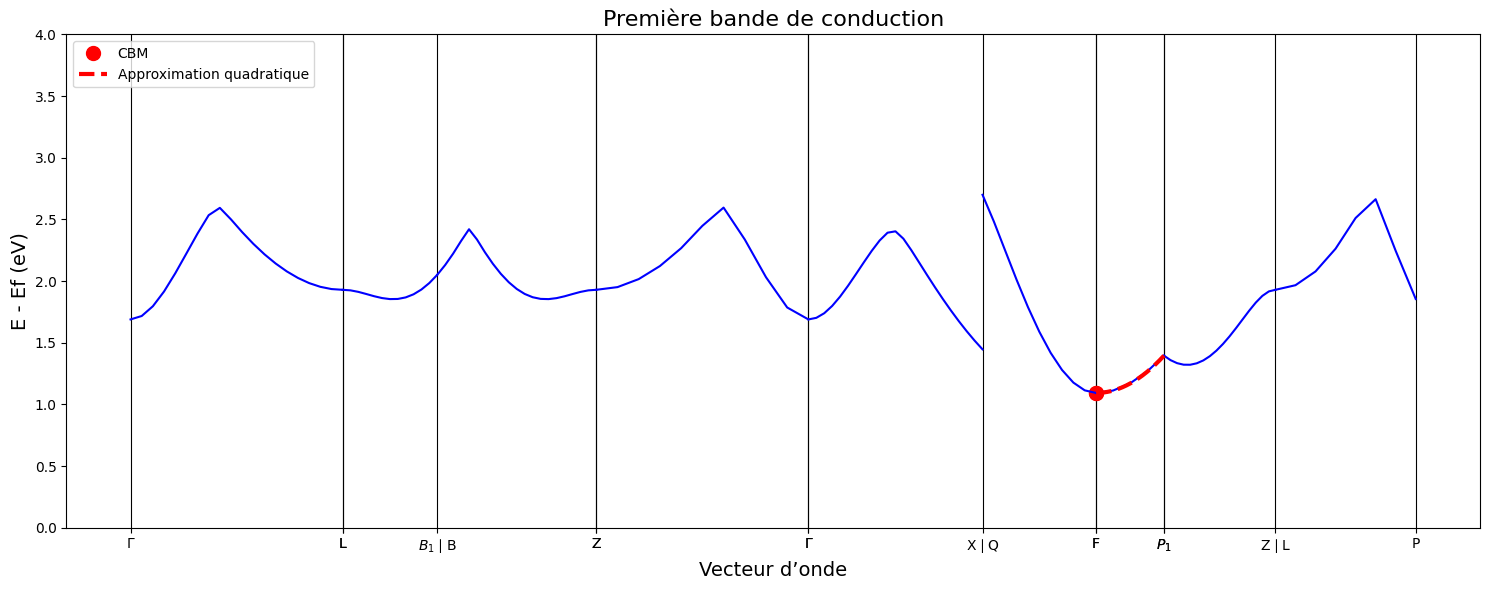

In [126]:
# ==============================
# FIGURE
# ==============================
fig, ax = plt.subplots(figsize=(15, 6))

# lignes verticales
for d in distance:
    ax.axvline(d, color="black", linewidth=0.8)

# CBM point
for i, (x, y) in enumerate(cbm_coord):
    if i == 0:
        ax.plot(x, y, 'or', markersize=10, label='CBM')
    else:
        ax.plot(x, y, 'or', markersize=10)

# bande de conduction
for i in range(len(distances)):
    ax.plot(distances[i], energy['1'][i][cbm_band_index], 'b')

# axes
ax.set_xticks(distance)
ax.set_xticklabels(bsdata['ticks']['label'])
ax.set_xlabel('Vecteur d’onde', fontsize=14)
ax.set_ylabel('E - Ef (eV)', fontsize=14)
ax.set_title('Première bande de conduction', fontsize=16)
ax.set_ylim(0, 4)

# ==============================
# TROUVER AUTOMATIQUEMENT LE SEGMENT DU CBM
# ==============================
k0, E0 = cbm_coord[0]

segment_cbm = None
index_k = None

for i in range(len(distances)):
    for j in range(len(distances[i])):
        if abs(distances[i][j] - k0) < 1e-5:
            segment_cbm = i
            index_k = j

# ==============================
# SELECTION DES 3 POINTS (comme correctif)
# ==============================
k_points_cbm = np.zeros(3)
energies_cbm = np.zeros(3)

# point central = CBM
k_points_cbm[1] = distances[segment_cbm][index_k]
energies_cbm[1] = energy['1'][segment_cbm][cbm_band_index][index_k]

# point gauche
k_points_cbm[0] = distances[segment_cbm][index_k - 1]
energies_cbm[0] = energy['1'][segment_cbm][cbm_band_index][index_k - 1]

# point droite
k_points_cbm[2] = distances[segment_cbm][index_k + 1]
energies_cbm[2] = energy['1'][segment_cbm][cbm_band_index][index_k + 1]

# ==============================
# FIT PARABOLIQUE
# ==============================
coeffs_cbm = np.polyfit(k_points_cbm, energies_cbm, 2)

m_e = 9.10938356e-31  # kg
m_eff_cbm = hbar2 / (2 * abs(coeffs_cbm[0]) * electronvolt * angstrom**2)
m_eff_ratio_cbm = m_eff_cbm / m_e

# ==============================
# RESULTATS
# ==============================
print("\nRésultats de l'ajustement quadratique autour du CBM :\n")
print(f"Parabole : y(k) = {coeffs_cbm[0]:.3e}·k² + {coeffs_cbm[1]:.3e}·k + {coeffs_cbm[2]:.3e}")
print(f"Dérivée seconde : {2 * coeffs_cbm[0]:.3e} eV·Å²")
print(f"Masse effective : {m_eff_cbm:.3e} kg")
print(f"Masse relative : {m_eff_ratio_cbm:.3f} m_e")

# ==============================
# PARABOLE (LOCAL MAIS VISIBLE)
# ==============================
x_fit_cbm = np.linspace(
    distances[segment_cbm][0],
    distances[segment_cbm][-1],
    500
)

ax.plot(x_fit_cbm, np.polyval(coeffs_cbm, x_fit_cbm),
        'r--', linewidth=3, label='Approximation quadratique')

ax.legend()
plt.tight_layout()
plt.show()

### Masse effective des électrons dans la bande de conduction 

Pour estimer la masse effective des électrons dans la première bande de conduction du matériau **Ba₂NF**, nous avons appliqué une approximation quadratique autour du minimum de la bande (CBM). En effet, à proximité d’un minimum d’énergie, la dispersion électronique peut être approchée par une parabole :

$$
E(k) \approx a k^2 + b k + c
$$

L’ajustement réalisé à partir de trois points proches du CBM donne l’équation suivante :

$$
y(k) = 3.518\, k^2 - 2.916 \times 10^1\, k + 6.150 \times 10^1
$$

La dérivée seconde de cette parabole est :

$$
\frac{d^2E}{dk^2} = 7.037 \ \mathrm{eV \cdot \AA^2}
$$

Ce qui permet de calculer la masse effective des électrons à partir de la formule :

$$
m^* = \frac{\hbar^2}{\frac{d^2E}{dk^2}}
$$

On obtient ainsi :

$$
m^* = 9.864 \times 10^{-31} \ \text{kg}
$$

Cette valeur représente environ :

$$
\frac{m^*}{m_e} \approx 1.083
$$

Cela signifie que les électrons dans cette bande de conduction ont une masse effective légèrement supérieure à celle d’un électron libre. Cela traduit une dispersion modérée de la bande de conduction : les électrons présentent une mobilité intermédiaire dans ce matériau.

## X1. Structures des bandes de phonons ##


PhononBandStructureSymmLine(bands=(12, 119), labels=['\\Gamma', 'L', 'B_1', 'B', 'Z', 'X', 'Q', 'F', 'P_1', 'P'])


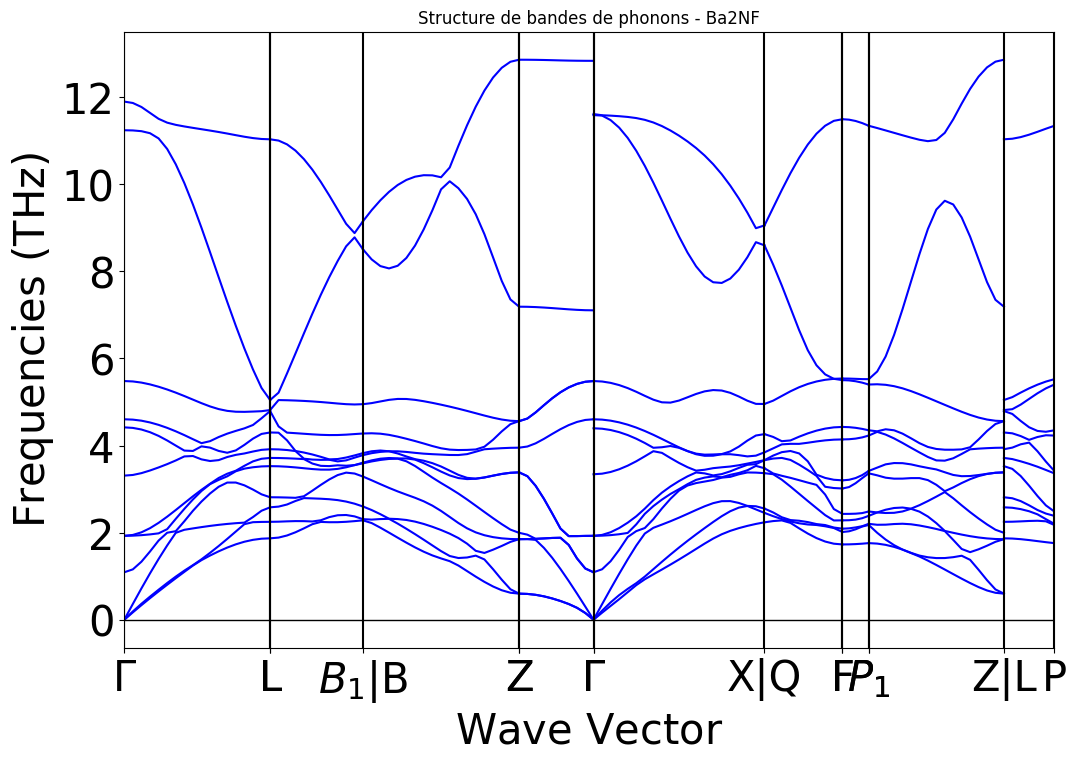

In [108]:
from pymatgen.phonon.plotter import PhononBSPlotter
import matplotlib.pyplot as plt

with MPRester("oq0PgNNYTST8xQ2xXfJpkLwNQFB5QgBT") as mpr:
    phonon_bs = mpr.get_phonon_bandstructure_by_material_id("mp-1018096")

print(phonon_bs)
plotter = PhononBSPlotter(phonon_bs)
plotter.get_plot()
plt.title("Structure de bandes de phonons - Ba2NF")
plt.show()

Nous pouvons ainsi connaitre les indices associés à chaque direction.

## X2. Zone de Brillouin

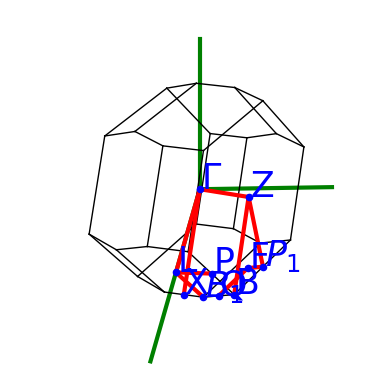

In [109]:
plotter.plot_brillouin()

Il existe 3 branches acoustiques dans un cristal : une branche longitudinale et deux branches transverses. Les branches acoustiques sont celles qui ont une fréquence nulle au centre  de la zone de Brillouin (point $\Gamma$). Nous pouvons donc voir que le $Ba_2NF$ a des branches acoustiques dans les directions $\Gamma$-L, $\Gamma$-Z et $\Gamma$-X.

## X3. Calcul des vitesses du son pour les 3 branches acoustiques

On peut avoir la vitesse du son dans le matériau en calculant la valeur absolue de la pente des courbes correspondant aux modes acoustiques car la vitesse du son est donnée par :
$$
v = \frac{d\omega}{dk}
$$
avec l'hypothèse que la relation de dispersion des phonons est supposée linéaire proche de $q = 0$  (le point $\Gamma$ sur l'axe des vecteurs d'onde).<br>
<br>
On utilise la relation liant la fréquence à la pulsation: $w = 2\pi f$.


### vitesse du son dans la première direction  $\Gamma$-L pour la branche 1

In [ ]:
data = plotter.bs_plot_data()
distances = data.get('distances')
frequences = data.get('frequency')
directions  = data.get('ticks').get('label')

dy1 = frequences[0][0][1] - frequences[0][0][0]
dx1 = distances[0][1] - distances[0][0]

v_1 = np.abs(2*np.pi*dy1*10**2 / dx1)
print("La vitesse du son pour la branche Γ-L : ", v_1, "[m/s]")

La vitesse du son pour la branche Γ-L :  1943.062952719536 [m/s]


### vitesse dans la deuxième direction $\Gamma$-Z pour la branche 2

In [ ]:
dy2 = frequences[3][1][-1]-frequences[3][1][-2]
dx2 = distances[3][-1] - distances[3][-2]
v_2 =  np.abs(2*np.pi*dy2*10**2 / dx2)
print("La vitesse du son pour la branche Γ-Z  : ", v_2, "[m/s]")



La vitesse du son pour la branche Γ-Z  :  1850.8075152554102 [m/s]


### vitesse dans la troixième direction $\Gamma$-X pour la branche 3

In [ ]:
dy3 = frequences[4][2][1] - frequences[4][2][0]
dx3 = distances[4][1] - distances[4][0]
v_3 =  np.abs(2*np.pi*dy3*10**2 / dx3)
print("La vitesse du son pour la branche Γ-X  : ", v_3, "[m/s]")

La vitesse du son pour la branche Γ-X  :  4114.1791348278775 [m/s]


On peut voir que la vitesse dans la troisième direction est plus grande que les vitesses dans les deux autres directions qui sont assez proches (en sachant qu'on a pris une branche diffèrente pour chaque direction). La vitesse la plus élevée correspond à la branche longitudinale et les vitesses plus faibles sont associées aux branches transverses.

Dans la branche longitudinale, les atomes vibrent parallèlement à la direction de propagation de l'onde alors que dans les branches transverses les atomes vibrent perpendiculairement à la direction de propagation.

### Calcul des Températures d'Einstein et de Debye en utilisant les moindres carrés sur les capacités calorifiques

In [ ]:
def calculate_einstein_cv(te, temperature):
    return 3 * N_at * sc.constants.R * (te / temperature)**2 * np.exp(te / temperature) / (np.exp(te / temperature) - 1)**2

def calculate_debye_cv(td, temperature):
    integral, _ = sc.integrate.quad(lambda t: (t**4 * np.exp(t)) / (np.exp(t) - 1)**2, 0, td/temperature)
    return 9 * N_at * sc.constants.R * (temperature / td)**3 * integral

T = np.array(range(5, 500))
t_einstein = sc.optimize.least_squares(lambda te: np.ravel([calculate_einstein_cv(te, T[i]) - ph_dos.cv(T[i]) for i in range(len(T))]), x0=100)
t_debye = sc.optimize.least_squares(lambda td: np.ravel([calculate_debye_cv(td, T[i]) - ph_dos.cv(T[i]) for i in range(len(T))]), x0=100)
print(f"Température d'Einstein: {t_einstein.x[0]} K")
print(f"Température de Debye: {t_debye.x[0]} K")

Température d'Einstein: 182.24637660018487 K
Température de Debye: 247.61953332280453 K


On constate logiquement que la température de Debye est supérieure à celle d'Einstein. En effet, la température d'Einstein est associée à une fréquence de vibration unique (agissant comme une moyenne), tandis que la température de Debye est définie par la fréquence de coupure maximale d'un spectre continu. Cette fréquence limite étant supérieure à la fréquence moyenne, la température de Debye l'est également.

### Plot des Capacités Calorifiques

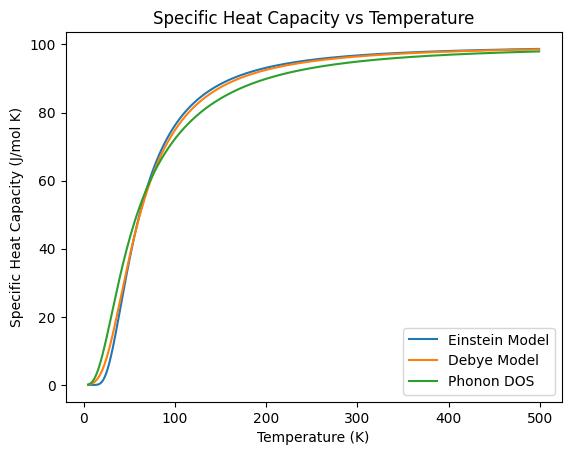

In [ ]:
cv_einstein = [calculate_einstein_cv(t_einstein.x[0], T[i]) for i in range(len(T))]
cv_debye = [calculate_debye_cv(t_debye.x[0], T[i]) for i in range(len(T))]
cv_ph_dos = [ph_dos.cv(T[i]) for i in range(len(T))]
plt.figure()
plt.plot(T, cv_einstein, label="Einstein Model")
plt.plot(T, cv_debye, label="Debye Model")
plt.plot(T, cv_ph_dos, label="Phonon DOS")
plt.xlabel("Temperature (K)")
plt.ylabel("Specific Heat Capacity (J/mol K)")
plt.title("Specific Heat Capacity vs Temperature")
plt.legend()
plt.show()

On observe bien que la courbe correspondant au modèle de Debye est au dessus de celle correspondant au modèle d'Einstein (quand T->0, Cv décroit en T^3 selon le modèle de Debye alors que le modèle d'Einstein décroit exponentiellemnent et donc beaucoup plus rapidement).

### Comparaison des densités d'états des modèles

Frequencies from DOS: -0.07237652312794202 THz to 15.576789784475361 THz


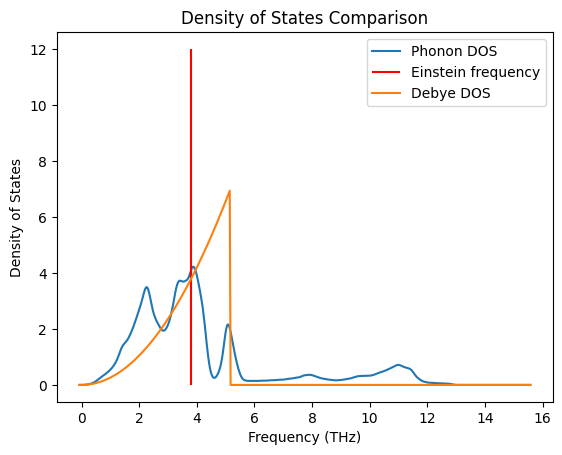

Fréquence d'Einstein: 3.7973983358245706 THz
Fréquence de Debye: 5.159553903343398 THz
Frequences expérimentales: -0.07237652312794202 THz to 15.576789784475361 THz


In [ ]:
f_d = t_debye.x[0] * sc.constants.k / sc.constants.h * 1e-12  # Convert to THz
f_e = t_einstein.x[0] * sc.constants.k / sc.constants.h * 1e-12  # Convert to THz

frequencies = np.array(ph_dos.frequencies)
dos = np.array(ph_dos.densities)

def debye_dos(frequency):
    if(frequency <= f_d):
        return 9 * N_at * (frequency)**2 / ((f_d)**3)
    else:
        return 0

print(f"Frequencies from DOS: {frequencies[0]} THz to {frequencies[-1]} THz")
d_dos = [debye_dos(f) for f in frequencies]  # Convert THz to Hz

plt.figure()
plt.plot(frequencies, dos, label="Phonon DOS")
plt.vlines(f_e, 0, 3*N_at, label="Einstein DOS", colors='r')
plt.plot(frequencies, d_dos, label="Debye DOS")
plt.xlabel("Frequency (THz)")
plt.ylabel("Density of States")
plt.title("Density of States Comparison")
plt.legend()
plt.show()

print(f"Fréquence d'Einstein: {f_e} THz")
print(f"Fréquence de Debye: {f_d} THz")
print(f"Frequences expérimentales: {frequencies[0]} THz to {frequencies[-1]} THz")

On voit que les majorités des états sont concentrés autour de l'intervalle [0 THz, 5 Thz] qui correspond aussi plus ou moins à l'intervalle sur laquelle le modèle de Debye prédit une occupation d'état non nul. De plus, autour de 0 les courbes expérimentale et du modèle de Debye sont alignées, bien que les données expérimentales montent assez rapidement au dessus de l'approximation de Debye. Le modèle d'Einstein fait l'approximation qu'un seul état est occupé ce qui donne cette grande droite.